Code to test the performance of shifting the data to account for misclassification errors from diffusion time in the testing environment.

In [ ]:
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR.joinpath('data')
ONNX_MODEL_DIR = ROOT_DIR.joinpath('onnx_models')
INDICES_DIR = ROOT_DIR.joinpath("saved_indices")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [11]:
df = pd.read_fwf(DATA_DIR.joinpath("ethylene_methane.txt"), skiprows=1, header=None, names=["Time", "Methane ppm", "Ethylene ppm", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"])
df.insert(1, "Target", df["Methane ppm"] > 0)
print(df)

            Time  Target  Methane ppm  Ethylene ppm       S1       S2  \
0           0.00   False          0.0           0.0   -41.98  2067.64   
1           0.01   False          0.0           0.0   -46.50  2067.88   
2           0.02   False          0.0           0.0   -36.16  2055.81   
3           0.03   False          0.0           0.0   -50.36  2053.68   
4           0.04   False          0.0           0.0   -37.30  2081.17   
...          ...     ...          ...           ...      ...      ...   
4178499  4179.00   False          0.0           0.0  2348.00  1599.20   
4178500  4179.00   False          0.0           0.0  2341.00  1605.30   
4178501  4179.00   False          0.0           0.0  2345.00  1604.00   
4178502  4179.00   False          0.0           0.0  2350.00  1594.80   
4178503  4179.00   False          0.0           0.0  2348.00  1598.80   

              S3       S4       S5       S6       S7       S8       S9  \
0         -37.13     2.28     8.63   -26.62    -8

In [ ]:
print("Number of True targets:", len(df[df['Target'].isin([True])]))
print("Number of False targets:", len(df[df['Target'].isin([False])]))

In [12]:
shifts = range(15, 25, 1)
for i in shifts:
    df.insert(1, f"Target_shifted_{i}", df["Target"].shift(i*100))

In [ ]:
shift18 = df[["Target_shifted_18", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift19 = df[["Target_shifted_19", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift20 = df[["Target_shifted_20", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift21 = df[["Target_shifted_21", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift22 = df[["Target_shifted_22", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()

shift18 = np.delete(shift18, np.s_[0:1800], axis=0)
shift19 = np.delete(shift19, np.s_[0:1900], axis=0)
shift20 = np.delete(shift20, np.s_[0:2000], axis=0)
shift21 = np.delete(shift21, np.s_[0:2100], axis=0)
shift22 = np.delete(shift22, np.s_[0:2200], axis=0)

In [ ]:
models = []
import xgboost as xgb
spw = len(df[df['Target'].isin([False])]) / len(df[df['Target'].isin([True])])
xgbm = xgb.XGBClassifier(
    n_estimators=3000, max_depth=3, learning_rate=0.01,
    scale_pos_weight=spw, tree_method="hist",
    subsample=0.5, colsample_bytree=0.5, min_child_weight=100,
    gamma=2.0, reg_alpha=0.5, reg_lambda=10.0,
    objective="binary:logistic", eval_metric="logloss",
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0,
)
models.append(xgbm)


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_scores = []
split = [.7, .15, .15]


for i in shifts:
    shifted = df[[f"Target_shifted_{i}", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
    shifted = np.delete(shifted, np.s_[0:i*100], axis=0)
    length = len(shifted)

    train_end = int(length * split[0])
    test_end = int(train_end + length * split[1])

    xtrain = shifted[:train_end, 1:]
    ytrain = shifted[:train_end, 0]
    xtest = shifted[train_end:test_end, 1:]
    ytest = shifted[train_end:test_end, 0]
    xval = shifted[test_end:length, 1:]
    yval = shifted[test_end:length, 0]

    accuracy_dict = {}

    for model in models:
        model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
        ypred = model.predict(xval)
        accuracy = accuracy_score(list(map(int,yval)), ypred)
        accuracy_dict[type(model).__name__] = accuracy
    accuracy_scores.append(accuracy_dict)

    i+=1

ValueError: x and y must have same first dimension, but have shapes (10,) and (3,)

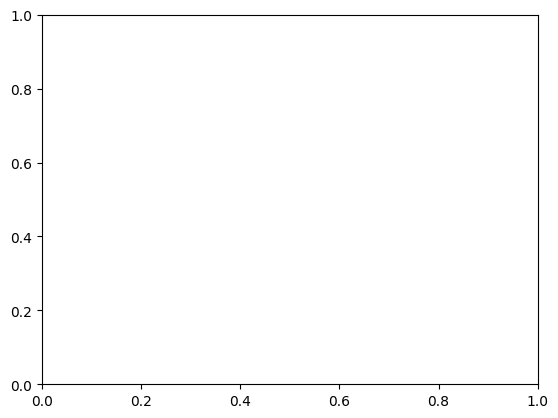

In [32]:
for model in models:
    axis = []
    for i in range(len(accuracy_scores)):
        axis.append(accuracy_scores[i][type(model).__name__])
    plt.plot(shifts, axis, label=type(model).__name__)
plt.legend()
plt.xlabel("Timeshift (s)")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
datasets = [shift18, shift19, shift20, shift21, shift22]

In [ ]:
spw = len(df[df['Target'].isin([False])]) / len(df[df['Target'].isin([True])])

model = xgb.XGBClassifier(
    n_estimators=3000, max_depth=3, learning_rate=0.01,
    scale_pos_weight=spw, tree_method="hist",
    subsample=0.5, colsample_bytree=0.5, min_child_weight=100,
    gamma=2.0, reg_alpha=0.5, reg_lambda=10.0,
    objective="binary:logistic", eval_metric="logloss",
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0,
)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_scores = []
split = [.7, .15, .15]
for dataset in datasets:
    length = len(dataset)

    train_end = int(length * split[0])
    test_end = int(train_end + length * split[1])

    xtrain = dataset[:train_end, 1:]
    ytrain = dataset[:train_end, 0]
    xtest = dataset[train_end:test_end, 1:]
    ytest = dataset[train_end:test_end, 0]
    xval = dataset[test_end:length, 1:]
    yval = dataset[test_end:length, 0]

    model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
    ypred = model.predict(xval)
    accuracy = accuracy_score(list(map(int,yval)), ypred)
    accuracy_scores.append(accuracy)

In [ ]:
plt.plot(["18s", "19s", "20s", "21s", "22s"], accuracy_scores)